# 🏥 Heart Disease Detection — Exploratory Data Analysis (EDA)
**Dataset:** Cleveland Heart Disease (UCI)

**Goal:** Understand the data before building the ANN model.

---

## 📦 Step 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!


## 📂 Step 2: Load Dataset

In [2]:
df = pd.read_csv(r'C:\Users\Pritam\Desktop\heart-disease\data\heart.csv')
print(f'✅ Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns')
df.head()

✅ Dataset loaded: 297 rows, 14 columns


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


## 🧾 Step 3: Column Description

| Column | Description |
|--------|-------------|
| `age` | Age of the patient |
| `sex` | Sex (1 = male, 0 = female) |
| `cp` | Chest pain type (0–3) |
| `trestbps` | Resting blood pressure (mm Hg) |
| `chol` | Serum cholesterol (mg/dl) |
| `fbs` | Fasting blood sugar > 120 mg/dl (1 = true) |
| `restecg` | Resting ECG results (0–2) |
| `thalach` | Maximum heart rate achieved |
| `exang` | Exercise induced angina (1 = yes) |
| `oldpeak` | ST depression induced by exercise |
| `slope` | Slope of peak exercise ST segment |
| `ca` | Number of major vessels (0–3) |
| `thal` | Thalassemia (0–3) |
| `target` | **1 = Heart Disease, 0 = No Disease** |

## 🔍 Step 4: Basic Info

In [3]:
print('--- Shape ---')
print(df.shape)

print('\n--- Data Types ---')
print(df.dtypes)

print('\n--- Missing Values ---')
print(df.isnull().sum())

--- Shape ---
(297, 14)

--- Data Types ---
age            int64
sex            int64
cp             int64
trestbps       int64
chol           int64
fbs            int64
restecg        int64
thalach        int64
exang          int64
oldpeak      float64
slope          int64
ca             int64
thal           int64
condition      int64
dtype: object

--- Missing Values ---
age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalach      0
exang        0
oldpeak      0
slope        0
ca           0
thal         0
condition    0
dtype: int64


In [4]:
# Statistical Summary
df.describe().T.style.background_gradient(cmap='Blues')

,count,mean,std,min,25%,50%,75%,max
age,297.000000,54.542088,9.049736,29.000000,48.000000,56.000000,61.000000,77.000000
sex,297.000000,0.676768,0.468500,0.000000,0.000000,1.000000,1.000000,1.000000
cp,297.000000,2.158249,0.964859,0.000000,2.000000,2.000000,3.000000,3.000000
trestbps,297.000000,131.693603,17.762806,94.000000,120.000000,130.000000,140.000000,200.000000
chol,297.000000,247.350168,51.997583,126.000000,211.000000,243.000000,276.000000,564.000000
fbs,297.000000,0.144781,0.352474,0.000000,0.000000,0.000000,0.000000,1.000000
restecg,297.000000,0.996633,0.994914,0.000000,0.000000,1.000000,2.000000,2.000000
thalach,297.000000,149.599327,22.941562,71.000000,133.000000,153.000000,166.000000,202.000000
exang,297.000000,0.326599,0.469761,0.000000,0.000000,0.000000,1.000000,1.000000
oldpeak,297.000000,1.055556,1.166123,0.000000,0.000000,0.800000,1.600000,6.200000


In [6]:
df.rename(columns={'condition': 'target'}, inplace=True)

## 🎯 Step 5: Target Variable Distribution

In [13]:
import os
print(os.getcwd())

c:\Users\Pritam\Downloads


In [14]:
import os
os.chdir(r'C:\Users\Pritam\Desktop\heart-disease')
os.makedirs('results', exist_ok=True)

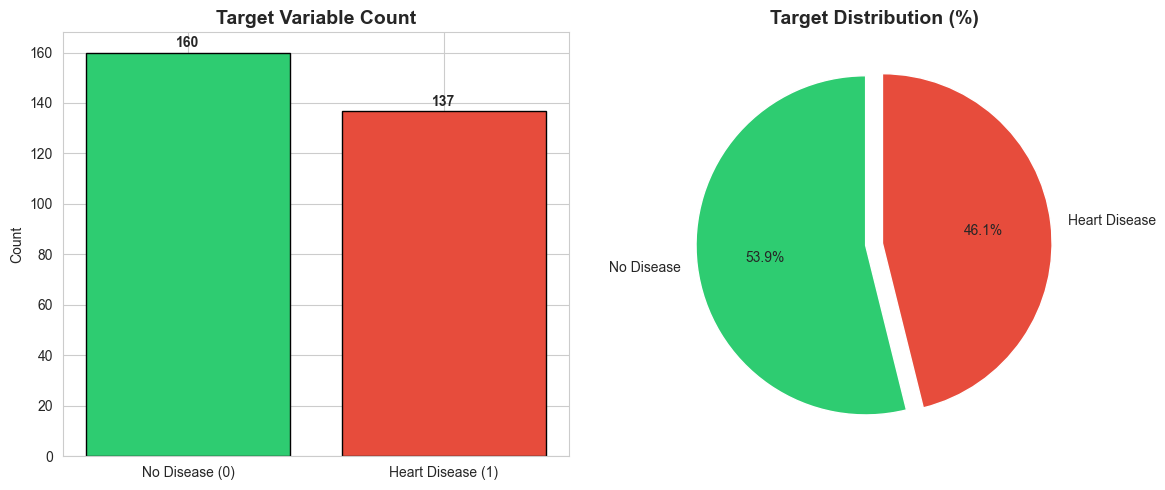


Class Balance:
target
0    160
1    137
Name: count, dtype: int64


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
counts = df['target'].value_counts()
axes[0].bar(['No Disease (0)', 'Heart Disease (1)'], counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Target Variable Count', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=['No Disease', 'Heart Disease'],
            colors=['#2ecc71', '#e74c3c'], autopct='%1.1f%%',
            startangle=90, explode=(0.05, 0.05))
axes[1].set_title('Target Distribution (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('results/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nClass Balance:\n{counts}')

## 👤 Step 6: Age & Sex Analysis

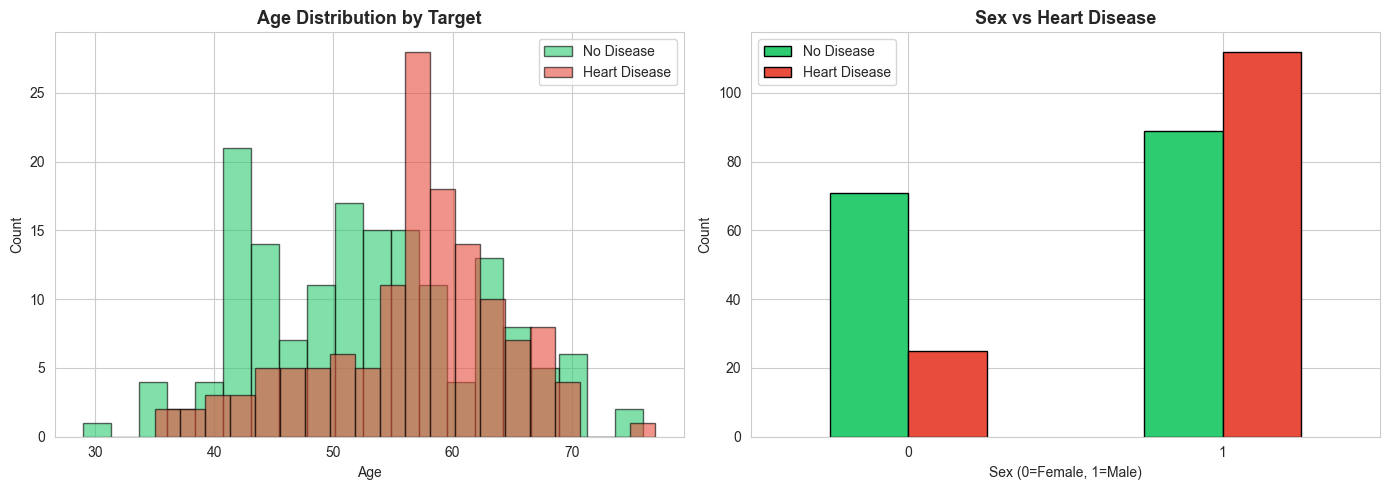

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age distribution by target
for target, color, label in zip([0, 1], ['#2ecc71', '#e74c3c'], ['No Disease', 'Heart Disease']):
    axes[0].hist(df[df['target'] == target]['age'], bins=20, alpha=0.6,
                 color=color, label=label, edgecolor='black')
axes[0].set_title('Age Distribution by Target', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].legend()

# Sex vs Target
sex_target = pd.crosstab(df['sex'], df['target'])
sex_target.plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'],
                edgecolor='black', rot=0)
axes[1].set_title('Sex vs Heart Disease', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Sex (0=Female, 1=Male)')
axes[1].set_ylabel('Count')
axes[1].legend(['No Disease', 'Heart Disease'])

plt.tight_layout()
plt.savefig('results/age_sex_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 💓 Step 7: Key Medical Features Analysis

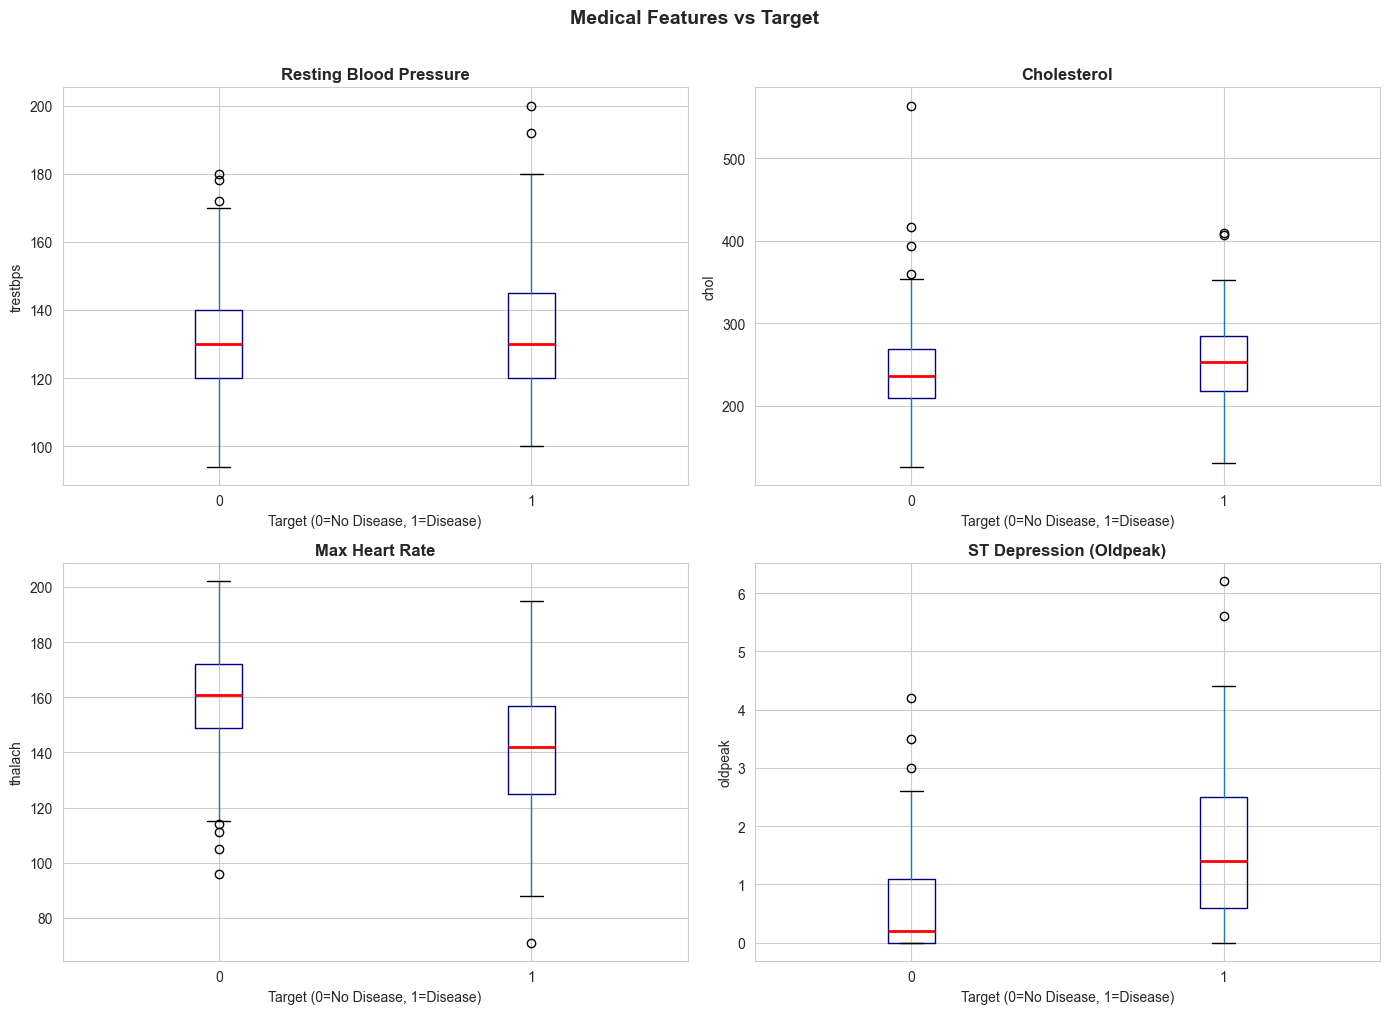

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

features = [
    ('trestbps', 'Resting Blood Pressure'),
    ('chol',     'Cholesterol'),
    ('thalach',  'Max Heart Rate'),
    ('oldpeak',  'ST Depression (Oldpeak)')
]

for ax, (col, title) in zip(axes.flatten(), features):
    df.boxplot(column=col, by='target', ax=ax,
               boxprops=dict(color='navy'),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Target (0=No Disease, 1=Disease)')
    ax.set_ylabel(col)

plt.suptitle('Medical Features vs Target', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('results/medical_features.png', dpi=150, bbox_inches='tight')
plt.show()

## 📊 Step 8: Categorical Features Analysis

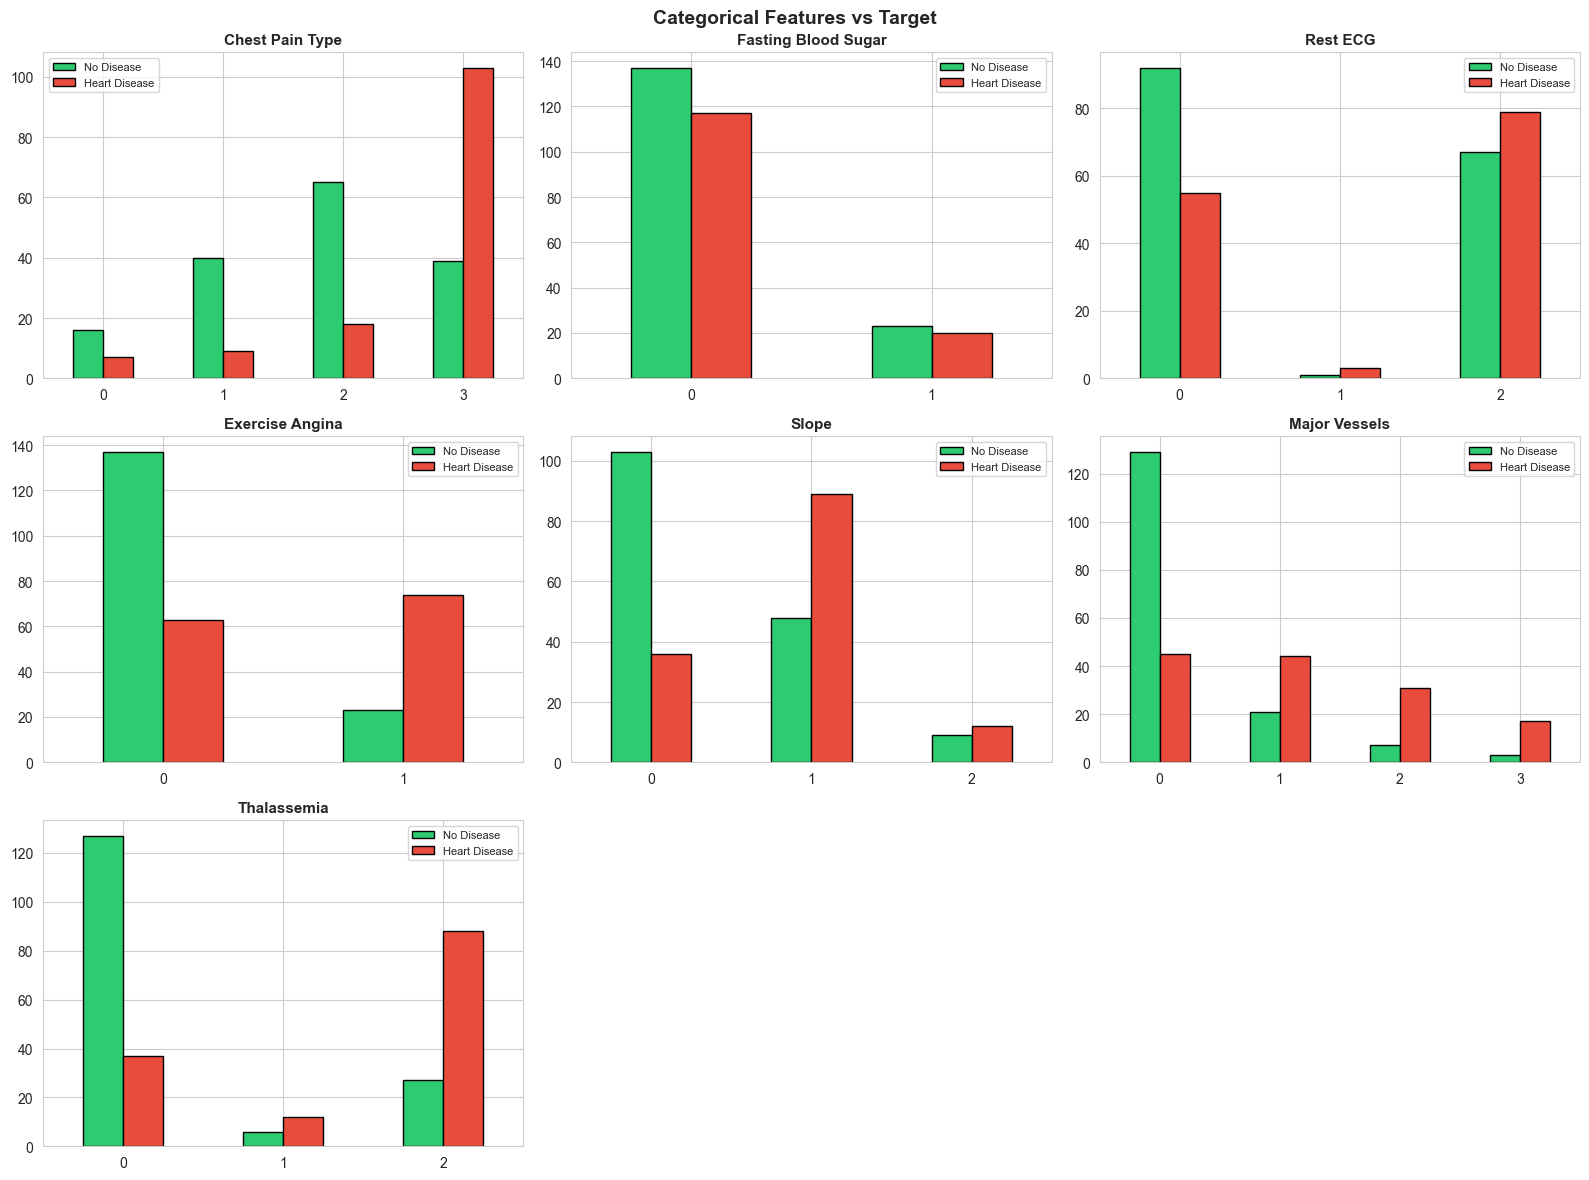

In [19]:
cat_features = ['cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
cat_labels = ['Chest Pain Type', 'Fasting Blood Sugar', 'Rest ECG',
              'Exercise Angina', 'Slope', 'Major Vessels', 'Thalassemia']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, (col, label) in enumerate(zip(cat_features, cat_labels)):
    ct = pd.crosstab(df[col], df['target'])
    ct.plot(kind='bar', ax=axes[i], color=['#2ecc71', '#e74c3c'],
            edgecolor='black', rot=0)
    axes[i].set_title(label, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].legend(['No Disease', 'Heart Disease'], fontsize=8)

# Hide empty subplot
axes[-1].set_visible(False)
axes[-2].set_visible(False)

plt.suptitle('Categorical Features vs Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/categorical_features.png', dpi=150, bbox_inches='tight')
plt.show()

## 🔥 Step 9: Correlation Heatmap

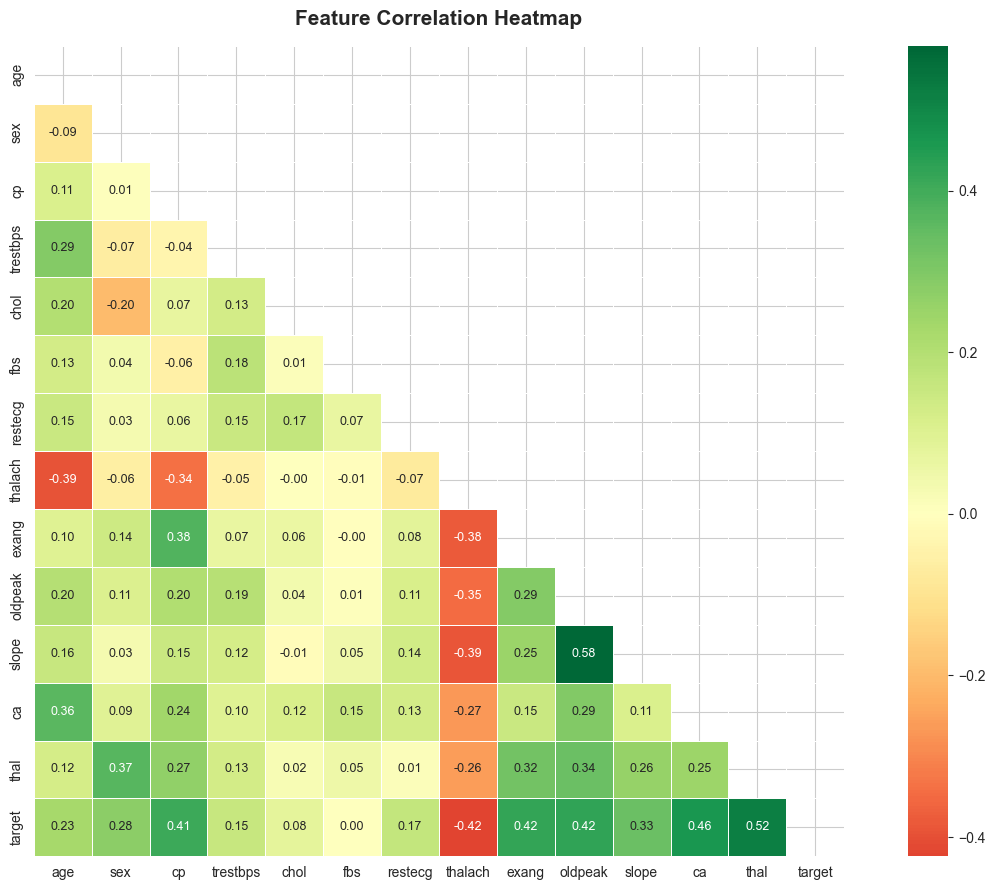

In [20]:
plt.figure(figsize=(13, 9))
corr = df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0,
            linewidths=0.5, square=True,
            annot_kws={'size': 9})

plt.title('Feature Correlation Heatmap', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('results/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 📈 Step 10: Feature Correlation with Target

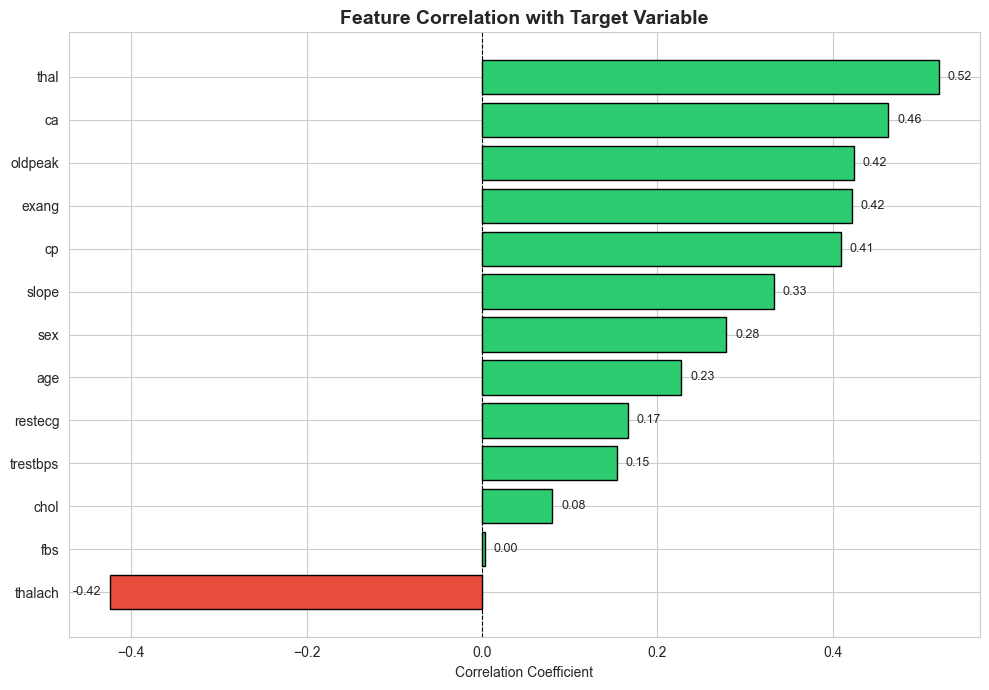


📌 Top Positive Correlations with Heart Disease:
thal        0.520516
ca          0.463189
oldpeak     0.424052
exang       0.421355
cp          0.408945
slope       0.333049
sex         0.278467
age         0.227075
restecg     0.166343
trestbps    0.153490
chol        0.080285
fbs         0.003167
Name: target, dtype: float64

📌 Top Negative Correlations:
thalach   -0.423817
Name: target, dtype: float64


In [21]:
target_corr = df.corr()['target'].drop('target').sort_values()

colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in target_corr.values]

plt.figure(figsize=(10, 7))
bars = plt.barh(target_corr.index, target_corr.values, color=colors, edgecolor='black')
plt.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
plt.title('Feature Correlation with Target Variable', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Coefficient')

for bar, val in zip(bars, target_corr.values):
    plt.text(val + (0.01 if val >= 0 else -0.01), bar.get_y() + bar.get_height()/2,
             f'{val:.2f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.savefig('results/feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📌 Top Positive Correlations with Heart Disease:')
print(target_corr[target_corr > 0].sort_values(ascending=False))
print('\n📌 Top Negative Correlations:')
print(target_corr[target_corr < 0].sort_values())

## 📋 Step 11: EDA Summary & Key Insights

In [22]:
print('=' * 55)
print('         EDA SUMMARY — HEART DISEASE DATASET')
print('=' * 55)
print(f'Total Samples        : {df.shape[0]}')
print(f'Total Features       : {df.shape[1] - 1}')
print(f'Missing Values       : {df.isnull().sum().sum()}')
print(f'Heart Disease Cases  : {df["target"].sum()} ({df["target"].mean()*100:.1f}%)')
print(f'No Disease Cases     : {(df["target"]==0).sum()} ({(1-df["target"].mean())*100:.1f}%)')
print(f'Age Range            : {df["age"].min()} – {df["age"].max()} years')
print(f'Avg Cholesterol      : {df["chol"].mean():.1f} mg/dl')
print(f'Avg Max Heart Rate   : {df["thalach"].mean():.1f} bpm')
print('=' * 55)
print('\n🔑 Key Insights:')
print('  ✅ Dataset is fairly balanced (~54% disease, ~46% no disease)')
print('  ✅ No missing values — clean dataset!')
print('  ✅ cp (chest pain), thalach, ca, thal are strong predictors')
print('  ✅ Males have more cases but females show higher risk ratio')
print('  ✅ Higher max heart rate correlates with heart disease')
print('  ✅ oldpeak and ca negatively correlate with disease')
print('\n➡️  Next Step: preprocess.py — Feature Scaling & Encoding')

         EDA SUMMARY — HEART DISEASE DATASET
Total Samples        : 297
Total Features       : 13
Missing Values       : 0
Heart Disease Cases  : 137 (46.1%)
No Disease Cases     : 160 (53.9%)
Age Range            : 29 – 77 years
Avg Cholesterol      : 247.4 mg/dl
Avg Max Heart Rate   : 149.6 bpm

🔑 Key Insights:
  ✅ Dataset is fairly balanced (~54% disease, ~46% no disease)
  ✅ No missing values — clean dataset!
  ✅ cp (chest pain), thalach, ca, thal are strong predictors
  ✅ Males have more cases but females show higher risk ratio
  ✅ Higher max heart rate correlates with heart disease
  ✅ oldpeak and ca negatively correlate with disease

➡️  Next Step: preprocess.py — Feature Scaling & Encoding
